In [ ]:
# W2D1 — Feature Engineering & Encoding

## Task 1: Categorical Encoding

This section demonstrates:
- OneHotEncoder
- OrdinalEncoder
- LabelEncoder

The trade-offs between the encoding methods are also discussed.

In [1]:
import sklearn

print("scikit-learn imported successfully")
print("Version:", sklearn.__version__)


scikit-learn imported successfully
Version: 1.9.0


In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

data = pd.DataFrame({
    "City": ["Bengaluru", "Mumbai", "Delhi", "Bengaluru", "Delhi"],
    "Education": ["Bachelor", "Master", "PhD", "Master", "Bachelor"],
    "Category": ["A", "B", "C", "A", "B"]
})

data

,City,Education,Category
0,Bengaluru,Bachelor,A
1,Mumbai,Master,B
2,Delhi,PhD,C
3,Bengaluru,Master,A
4,Delhi,Bachelor,B


In [3]:
# OneHotEncoder
one_hot = OneHotEncoder(sparse_output=False)

encoded_city = one_hot.fit_transform(data[["City"]])

one_hot_df = pd.DataFrame(
    encoded_city,
    columns=one_hot.get_feature_names_out(["City"])
)

one_hot_df

,City_Bengaluru,City_Delhi,City_Mumbai
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0


In [4]:
# OrdinalEncoder
ordinal = OrdinalEncoder(
    categories=[["Bachelor", "Master", "PhD"]]
)

encoded_education = ordinal.fit_transform(data[["Education"]])

ordinal_df = pd.DataFrame(
    encoded_education,
    columns=["Education_Encoded"]
)

ordinal_df


,Education_Encoded
0,0.0
1,1.0
2,2.0
3,1.0
4,0.0


In [5]:
# LabelEncoder
label = LabelEncoder()

encoded_category = label.fit_transform(data["Category"])

label_df = pd.DataFrame(
    encoded_category,
    columns=["Category_Encoded"]
)

label_df

,Category_Encoded
0,0
1,1
2,2
3,0
4,1


In [ ]:
## Encoding Trade-offs

### OneHotEncoder
- Creates separate binary columns for each category.
- Does not imply any numerical order.
- Best for nominal categorical features.
- Can create many columns when there are many categories.

### OrdinalEncoder
- Converts categories into ordered numerical values.
- Suitable when categories have a meaningful order.
- The category order must be defined correctly.
- Not suitable for categories with no natural ranking.

### LabelEncoder
- Converts labels into numerical values.
- Simple and useful for encoding target labels.
- Can incorrectly imply an order when used for input features.
- Therefore, it should generally be avoided for nominal input features.

### Conclusion

The encoding method should be selected based on the type of categorical feature 
and whether the categories have a meaningful order.

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Sample numerical data
numeric_data = pd.DataFrame({
    "Age": [20, 22, 25, 30, 35],
    "Salary": [25000, 30000, 40000, 60000, 100000]
})

numeric_data

,Age,Salary
0,20,25000
1,22,30000
2,25,40000
3,30,60000
4,35,100000


In [7]:
# StandardScaler
standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(numeric_data)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=numeric_data.columns
)

standard_df

,Age,Salary
0,-1.171603,-0.953206
1,-0.805477,-0.769897
2,-0.256288,-0.403280
3,0.659027,0.329956
4,1.574342,1.796427


In [8]:
# MinMaxScaler
minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(numeric_data)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=numeric_data.columns
)

minmax_df

,Age,Salary
0,0.000000,0.000000
1,0.133333,0.066667
2,0.333333,0.200000
3,0.666667,0.466667
4,1.000000,1.000000


In [9]:
# RobustScaler
robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(numeric_data)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=numeric_data.columns
)

robust_df

,Age,Salary
0,-0.625,-0.500000
1,-0.375,-0.333333
2,0.000,0.000000
3,0.625,0.666667
4,1.250,2.000000


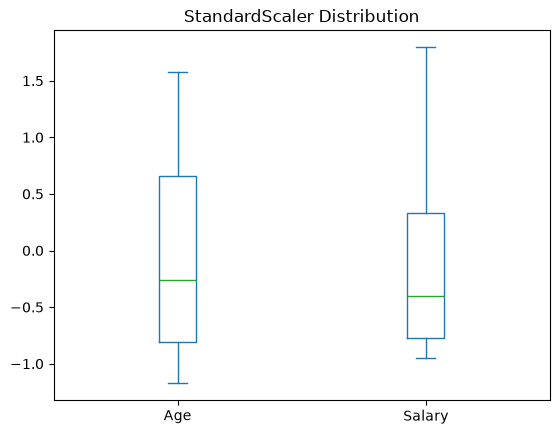

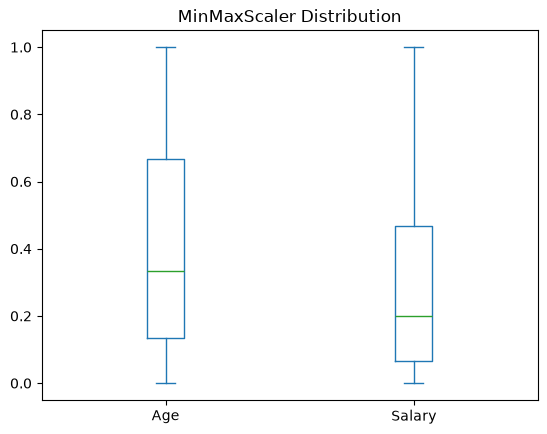

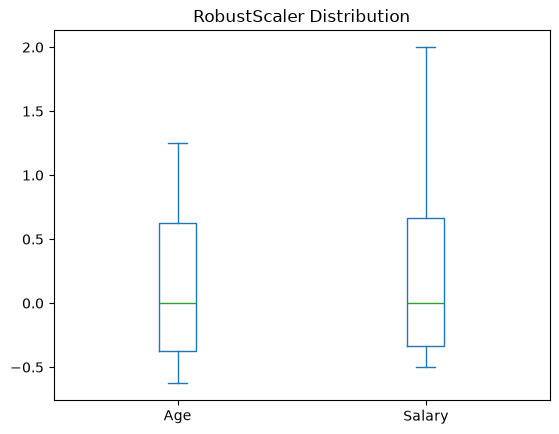

In [10]:
import matplotlib.pyplot as plt

# Compare scaled distributions
standard_df.plot(kind="box")
plt.title("StandardScaler Distribution")
plt.show()

minmax_df.plot(kind="box")
plt.title("MinMaxScaler Distribution")
plt.show()

robust_df.plot(kind="box")
plt.title("RobustScaler Distribution")
plt.show()

In [ ]:
## Scaling Comparison

- StandardScaler standardizes features around mean 0 with standard deviation 1.
- MinMaxScaler transforms features to a range between 0 and 1.
- RobustScaler uses the median and interquartile range (IQR), making it more resistant to outliers.

### Conclusion

StandardScaler is useful when features need standardization.
MinMaxScaler is useful when a fixed range such as 0 to 1 is required.
RobustScaler is a good choice when the dataset contains significant outliers.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

# Sample dataset with 6 features
feature_data = pd.DataFrame({
    "Age": [20, 22, 25, 30, 35, 40, 45, 50],
    "Salary": [25000, 30000, 40000, 60000, 100000, 120000, 140000, 160000],
    "Experience": [1, 2, 3, 5, 8, 10, 15, 20],
    "Score": [55, 60, 65, 70, 80, 85, 90, 95],
    "Hours_Study": [2, 3, 4, 5, 6, 7, 8, 9],
    "Projects": [1, 1, 2, 3, 5, 6, 8, 10]
})

# Target variable
target = [0, 0, 0, 1, 1, 1, 1, 1]

feature_data

,Age,Salary,Experience,Score,Hours_Study,Projects
0,20,25000,1,55,2,1
1,22,30000,2,60,3,1
2,25,40000,3,65,4,2
3,30,60000,5,70,5,3
4,35,100000,8,80,6,5
5,40,120000,10,85,7,6
6,45,140000,15,90,8,8
7,50,160000,20,95,9,10


In [13]:
# Select the top 5 features
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(feature_data, target)

selected_features = feature_data.columns[selector.get_support()]

print("Top 5 Features:")
print(list(selected_features))



Top 5 Features:
['Age', 'Salary', 'Score', 'Hours_Study', 'Projects']


In [14]:
# Display feature scores
feature_scores = pd.DataFrame({
    "Feature": feature_data.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

feature_scores

,Feature,Score
3,Score,15.428571
4,Hours_Study,15.000000
0,Age,13.367703
1,Salary,13.254210
5,Projects,9.669643
2,Experience,7.240223


In [ ]:
## SelectKBest — Top 5 Features

The SelectKBest method was used with ANOVA F-test (`f_classif`) to identify the five features with
 the strongest statistical relationship with the target variable.

### Selected Features

1. Score — 15.43
2. Hours_Study — 15.00
3. Age — 13.37
4. Salary — 13.25
5. Projects — 9.67

### Feature Importance Explanation

- **Score:** Strong relationship with the target and received the highest score.
- **Hours_Study:** Shows a strong relationship with the target.
- **Age:** Provides useful information for distinguishing the target classes.
- **Salary:** Has a strong statistical relationship with the target.
- **Projects:** Provides useful predictive information.

**Experience** was not selected because it had the lowest SelectKBest score among the six features.

### Conclusion

SelectKBest helps reduce the number of features by selecting the features with the strongest statistical relationship
 with the target. This can simplify the model and reduce unnecessary features.

In [ ]:
# W2D1 Summary

## Completed Tasks

- ✓ OneHotEncoder demonstrated
- ✓ OrdinalEncoder demonstrated
- ✓ LabelEncoder demonstrated
- ✓ Encoding trade-offs documented
- ✓ StandardScaler applied
- ✓ MinMaxScaler applied
- ✓ RobustScaler applied
- ✓ Scaling distributions compared using box plots
- ✓ SelectKBest applied
- ✓ Top 5 features identified
- ✓ Feature importance documented

## W2D1 Status

✓ COMPLETE